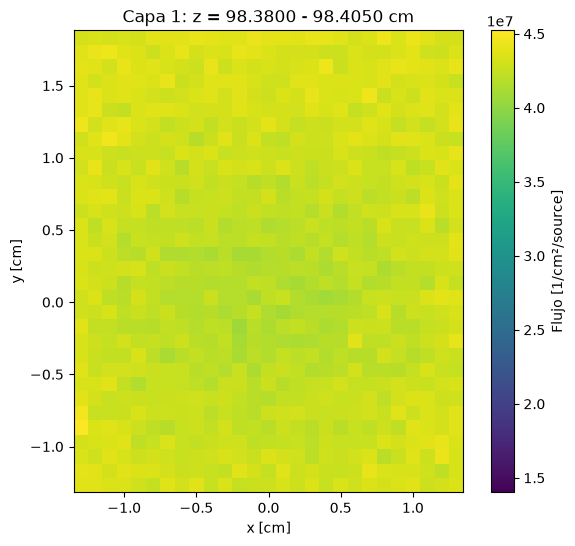

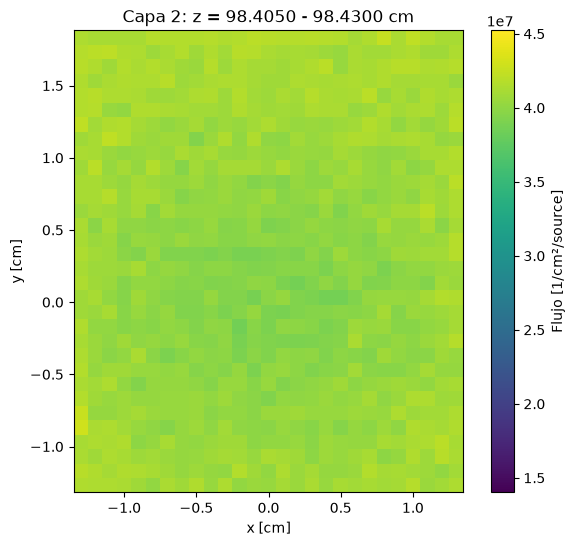

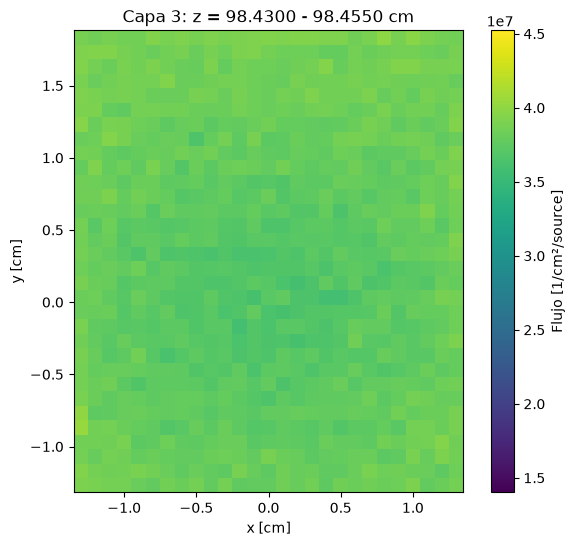

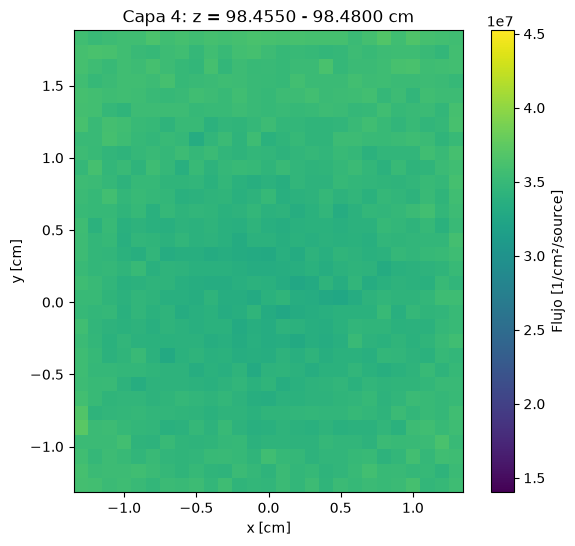

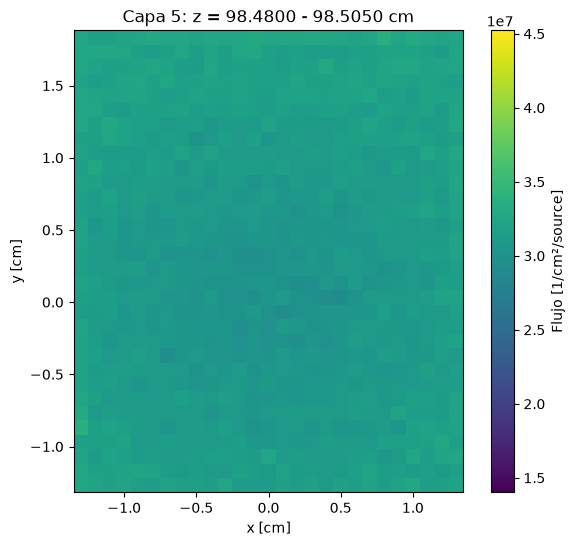

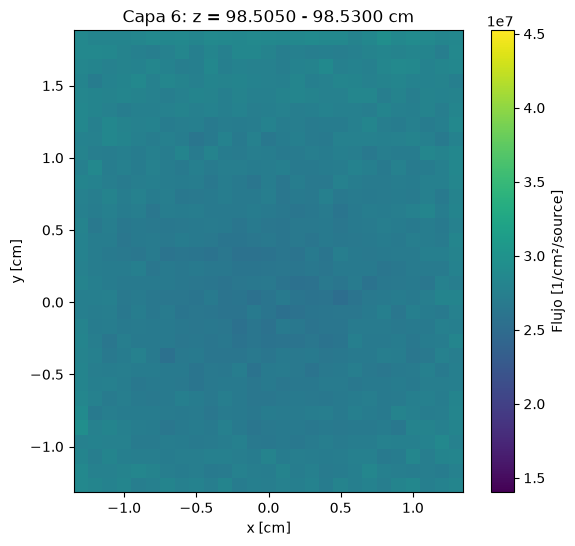

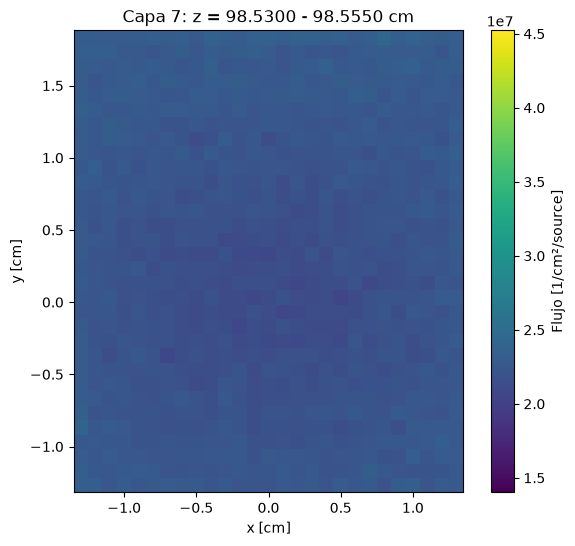

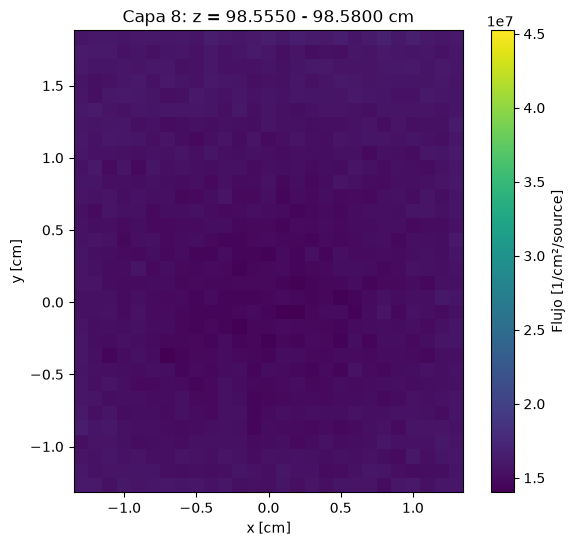

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

archivo = "../out/flujo_CR39_xyz.out"

nx = 27
ny = 32

xmin, xmax = -1.35, 1.35
ymin, ymax = -1.3185, 1.8815

mapas = {}
z_rangos = {}

mapa_actual = None
leyendo = False
datos = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:

        match = re.search(
            r"no\.\s*=\s*(\d+).*iz\s*=\s*(\d+)",
            linea
        )

        if match:
            if mapa_actual is not None and len(datos) >= nx * ny:
                mapas[mapa_actual] = np.array(datos[:nx * ny]).reshape(ny, nx)

            mapa_actual = int(match.group(2))
            datos = []
            leyendo = False

        match_z = re.search(
            r"#\s*z\s*=\s*\(\s*([0-9.E+-]+)\s*-\s*([0-9.E+-]+)",
            linea
        )

        if match_z and mapa_actual is not None:
            z_rangos[mapa_actual] = (
                float(match_z.group(1)),
                float(match_z.group(2))
            )

        if linea.startswith("hc:") and "x =" in linea and "y =" in linea:
            leyendo = True
            continue

        if leyendo:
            if linea.startswith("#"):
                leyendo = False
                continue

            for valor in linea.split():
                try:
                    datos.append(float(valor))
                except ValueError:
                    pass

if mapa_actual is not None and len(datos) >= nx * ny:
    mapas[mapa_actual] = np.array(datos[:nx * ny]).reshape(ny, nx)

vmin = min(np.min(m) for m in mapas.values())
vmax = max(np.max(m) for m in mapas.values())

for i in sorted(mapas):

    z1, z2 = z_rangos[i]

    plt.figure(figsize=(7, 6))

    im = plt.imshow(
        mapas[i],
        extent=[xmin, xmax, ymin, ymax],
        origin="upper",
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(
        im,
        label="Flujo [1/cm²/source]"
    )

    plt.xlabel("x [cm]")
    plt.ylabel("y [cm]")
    plt.title(
        f"Capa {i}: z = {z1:.4f} - {z2:.4f} cm"
    )

    plt.show()